# Misbehavior Detection in Vehicle-to-everything (V2X) Communication Using VeReMi Extension Dataset
**Akid Abrar | Civil, Construction and Environmental Engineering (Transportation)| Graduate (Ph.D.)**

**Task:** 20-class supervised classification of Basic Safety Messages (BSMs) as normal or one of 19 misbehavior types.

**Models:** Random Forest (primary), XGBoost, k-NN  
**Primary metric:** Macro-averaged F1-score  
**Graduate requirement:** Uncertainty quantification via RF probabilities, 5-fold CV, and XGBoost calibration curves

## 1. Background

### Vehicle-to-Everything (V2X) Communication
V2X is a class of wireless communication technology that allows vehicles to exchange data with their surroundings, i.e., other vehicles, roadside infrastructure , pedestrians , and the broader network. The goal is cooperative awareness: each vehicle continuously broadcasts its kinematics so that nearby road users can perceive the full traffic picture beyond their sensor range. This enables applications such as intersection collision warning, emergency vehicle preemption, platooning, and cooperative adaptive cruise control.

### Basic Safety Messages (BSMs)
A BSM  is a short, 10-Hz broadcast that every equipped vehicle transmits over the 5.9 GHz C-V2X channel. Each message encodes the vehicle's current kinematic state: position (GPS-derived lat, lon), speed, acceleration, and heading. Neighboring vehicles use these messages to maintain a local dynamic map of traffic. Because BSMs are unauthenticated and broadcast publicly, they are a primary attack surface in V2X networks.

### Misbehavior in V2X Networks
Misbehavior refers to the injection of false or misleading BSMs into the network, either because of a *faulty* on-board sensor (unintentional) or because of a *malicious* attacker deliberately crafting false messages. Consequences include traffic congestion, sudden break, ghost-vehicle hallucinations, and network congestion. Detecting misbehavior is critical for the trustworthiness of V2X safety applications.

The **VeReMi Extension Dataset** simulates a realistic Luxembourg city road network under multiple misbehavior injection scenarios. It provides ground-truth labels for 19 distinct attack/fault types alongside normal driving, making it a standard benchmark for supervised misbehavior detection research. It has 29 features and 1 target class.

---

### Feature Dictionary

The 16 kinematic features used in this study are drawn directly from the BSM payload. Each physical quantity appears twice: the *reported* value transmitted in the BSM, and a *noisy* version (suffix ) that represents the perturbed/received signal after channel noise.

| Feature | Full Name | Unit | Description |
|---------|-----------|------|-------------|
|  posx| Position X (reported) | m | East–West coordinate in the simulation grid |
|  posy| Position Y (reported) | m | North–South coordinate in the simulation grid |
|  posx_n| Position X (noisy) | m | Received/noisy version of the reported X position |
|  posy_n| Position Y (noisy) | m | Received/noisy version of the reported Y position |
|  spdx| Speed X (reported) | m/s | Velocity component along the East–West axis |
|  spdy| Speed Y (reported) | m/s | Velocity component along the North–South axis |
|  spdx_n| Speed X (noisy) | m/s | Received/noisy version of the reported X speed |
|  spdy_n| Speed Y (noisy) | m/s | Received/noisy version of the reported Y speed |
|  aclx| Acceleration X (reported) | m/s² | Longitudinal acceleration in the East–West direction |
|  acly| Acceleration Y (reported) | m/s² | Lateral acceleration in the North–South direction |
|  aclx_n| Acceleration X (noisy) | m/s² | Received/noisy version of the reported X acceleration |
|  acly_n| Acceleration Y (noisy) | m/s² | Received/noisy version of the reported Y acceleration |
|  hedx| Heading X (reported) | — | X-component of the unit heading vector (cos θ) |
|  hedy| Heading Y (reported) | — | Y-component of the unit heading vector (sin θ) |
|  hedx_n| Heading X (noisy) | — | Received/noisy version of the heading X component |
|  hedy_n| Heading Y (noisy) | — | Received/noisy version of the heading Y component |


In [1]:
# Cell 1
# Local Machine Setup : install dependencies and check GPU
import subprocess, sys

# Install required packages
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'numpy', 'pandas', 'matplotlib', 'seaborn',
                'scikit-learn', 'xgboost'], check=True)
print('Packages ready.')

# Check for CUDA GPU
try:
    result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total',
                             '--format=csv,noheader'], capture_output=True, text=True)
    if result.returncode == 0:
        print(f'GPU detected: {result.stdout.strip()}')
        GPU_AVAILABLE = True
    else:
        print('No NVIDIA GPU detected — XGBoost will fall back to CPU.')
        GPU_AVAILABLE = False
except FileNotFoundError:
    print('nvidia-smi not found — XGBoost will use CPU.')
    GPU_AVAILABLE = False


Packages ready.
GPU detected: NVIDIA RTX 2000 Ada Generation, 16380 MiB


In [2]:
# Cell 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score
)
from xgboost import XGBClassifier

SEED = 42
np.random.seed(SEED)

DATA_PATH = 'mixalldata_clean.csv'

CLASS_NAMES = [
    'Normal behavior',
    'Constant position', 'Constant position offset',
    'Random position', 'Random position offset',
    'Constant speed', 'Constant speed offset',
    'Random speed', 'Random speed offset',
    'Disruptive', 'Data replay',
    'DoS', 'DoS random', 'DoS disruptive',
    'Data replay sybil', 'Traffic congestion sybil',
    'DoS random sybil', 'DoS disruptive sybil',
    'Extended Attack A', 'Extended Attack B'
] #from the dataset paper

print('Libraries loaded.')

Libraries loaded.


## 2. Data Loading & Exploratory Analysis

The full dataset is ~1.21 GB (3.19 M rows).

In [3]:
# Cell 4
df_full = pd.read_csv(DATA_PATH)
print(f'Full dataset shape: {df_full.shape}')
df_full.info()

Full dataset shape: (3194808, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3194808 entries, 0 to 3194807
Data columns (total 30 columns):
 #   Column        Dtype  
---  ------        -----  
 0   type          int64  
 1   sendTime      float64
 2   sender        int64  
 3   senderPseudo  int64  
 4   messageID     int64  
 5   class         int64  
 6   posx          float64
 7   posy          float64
 8   posz          float64
 9   posx_n        float64
 10  posy_n        float64
 11  posz_n        float64
 12  spdx          float64
 13  spdy          float64
 14  spdz          float64
 15  spdx_n        float64
 16  spdy_n        float64
 17  spdz_n        float64
 18  aclx          float64
 19  acly          float64
 20  aclz          float64
 21  aclx_n        float64
 22  acly_n        float64
 23  aclz_n        float64
 24  hedx          float64
 25  hedy          float64
 26  hedz          float64
 27  hedx_n        float64
 28  hedy_n        float64
 29  hedz_n     

Class distribution of the dataset

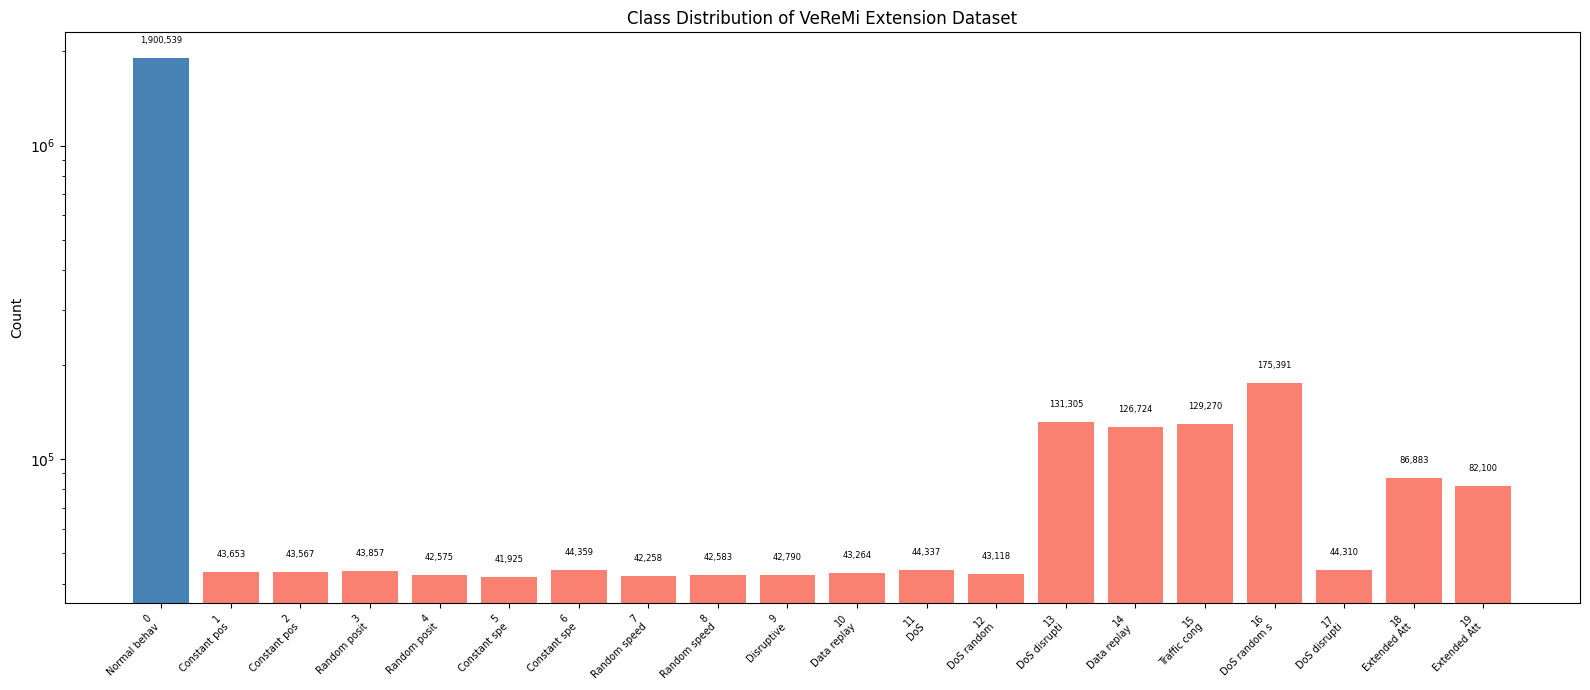


Class counts:
  Class  0 | Normal behavior                | 1,900,539
  Class  1 | Constant position              |   43,653
  Class  2 | Constant position offset       |   43,567
  Class  3 | Random position                |   43,857
  Class  4 | Random position offset         |   42,575
  Class  5 | Constant speed                 |   41,925
  Class  6 | Constant speed offset          |   44,359
  Class  7 | Random speed                   |   42,258
  Class  8 | Random speed offset            |   42,583
  Class  9 | Disruptive                     |   42,790
  Class 10 | Data replay                    |   43,264
  Class 11 | DoS                            |   44,337
  Class 12 | DoS random                     |   43,118
  Class 13 | DoS disruptive                 |  131,305
  Class 14 | Data replay sybil              |  126,724
  Class 15 | Traffic congestion sybil       |  129,270
  Class 16 | DoS random sybil               |  175,391
  Class 17 | DoS disruptive sybil           |   4

In [7]:
# Cell 5
# Class distribution
class_counts = df_full['class'].value_counts().sort_index()
class_labels  = [CLASS_NAMES[i] for i in class_counts.index]

fig, ax = plt.subplots(figsize=(16, 7))
bars = ax.bar(range(len(class_counts)), class_counts.values,
              color=['steelblue' if i == 0 else 'salmon' for i in class_counts.index])
ax.set_xticks(range(len(class_counts)))
ax.set_xticklabels([f'{i}\n{CLASS_NAMES[i][:12]}' for i in class_counts.index],
                    fontsize=7, rotation=45, ha='right')
ax.set_ylabel('Count')
ax.set_title('Class Distribution of VeReMi Extension Dataset')
ax.set_yscale('log')
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.1,
            f'{val:,}', ha='center', va='bottom', fontsize=6)
plt.tight_layout()
plt.show()
print('\nClass counts:')
for i, (count) in enumerate(class_counts):
    print(f'  Class {i:2d} | {CLASS_NAMES[i]:<30} | {count:>8,}')

Checking missing values and static columns (columns with zero variance)

In [ ]:
# Cell 6
# Missing values check
print('Missing values per column:')
print(df_full.isnull().sum())

# Static columns (zero variance)
static_cols = [c for c in df_full.columns if df_full[c].nunique() == 1]
print(f'\nStatic (constant) columns: {static_cols}')

Missing values per column:
type            0
sendTime        0
sender          0
senderPseudo    0
messageID       0
class           0
posx            0
posy            0
posz            0
posx_n          0
posy_n          0
posz_n          0
spdx            0
spdy            0
spdz            0
spdx_n          0
spdy_n          0
spdz_n          0
aclx            0
acly            0
aclz            0
aclx_n          0
acly_n          0
aclz_n          0
hedx            0
hedy            0
hedz            0
hedx_n          0
hedy_n          0
hedz_n          0
dtype: int64

Static (constant) columns: ['type', 'posz', 'posz_n', 'spdz', 'spdz_n', 'aclz', 'aclz_n', 'hedz', 'hedz_n']


Statistics of kinematic features

In [28]:
# Cell 7
# Descriptive statistics for key kinematic features
feature_cols_preview = ['posx', 'posy', 'spdx', 'spdy', 'aclx', 'acly', 'hedx', 'hedy']
round(df_full[feature_cols_preview + ['class']].describe(), 3)

,posx,posy,spdx,spdy,aclx,acly,hedx,hedy,class
count,3194808.000,3194808.000,3194808.000,3194808.000,3194808.000,3194808.000,3194808.000,3194808.000,3194808.000
mean,599.020,667.337,2.204,2.471,0.078,0.079,-0.041,0.036,4.843
std,391.581,305.649,10.238,10.121,1.017,1.153,0.678,0.709,6.732
min,-20.013,-22.480,-26.993,-27.872,-6.999,-4.500,-1.000,-1.000,0.000
25%,228.702,421.128,-3.165,-3.713,-0.227,-0.235,-0.705,-0.662,0.000
50%,550.812,704.533,0.001,0.187,0.000,0.000,-0.019,0.065,0.000
75%,914.702,898.325,8.141,8.003,0.388,0.461,0.601,0.727,12.000
max,1518.956,1522.609,40.000,40.000,4.506,4.504,1.000,1.000,19.000


## 3. Preprocessing

Drop non-feature columns (identifiers, timestamps, static zero-only columns).
Keep 16 kinematic features: position, speed, acceleration, and heading — both raw (x/y) and noisy (x_n/y_n).

In [30]:
# Cell 10
# Columns to drop:
# - 'type': constant (always 4)
# - z-axis columns: all zeros (posz, posz_n, spdz, spdz_n, aclz, aclz_n, hedz, hedz_n)
# - identifiers/timestamps: sendTime, sender, senderPseudo, messageID
# - helper columns we added: state

DROP_COLS = [
    'type',
    'posz', 'posz_n', 'spdz', 'spdz_n', 'aclz', 'aclz_n', 'hedz', 'hedz_n',
    'sendTime', 'sender', 'senderPseudo', 'messageID',
    'state'
]

FEATURE_COLS = [
    'posx', 'posy', 'posx_n', 'posy_n',
    'spdx', 'spdy', 'spdx_n', 'spdy_n',
    'aclx', 'acly', 'aclx_n', 'acly_n',
    'hedx', 'hedy', 'hedx_n', 'hedy_n'
]
TARGET_COL = 'class'

print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'Target: {TARGET_COL}')

Features (16): ['posx', 'posy', 'posx_n', 'posy_n', 'spdx', 'spdy', 'spdx_n', 'spdy_n', 'aclx', 'acly', 'aclx_n', 'acly_n', 'hedx', 'hedy', 'hedx_n', 'hedy_n']
Target: class


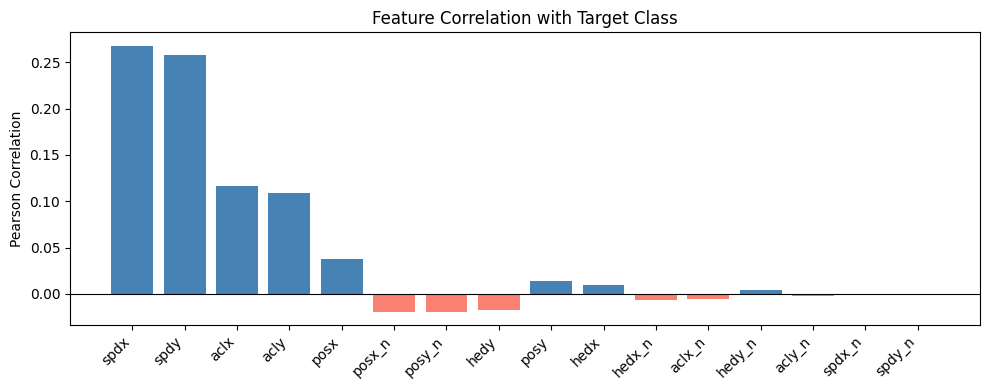


Correlation with class (sorted by |r|):
spdx      0.2679
spdy      0.2572
aclx      0.1168
acly      0.1087
posx      0.0382
posx_n   -0.0189
posy_n   -0.0189
hedy     -0.0178
posy      0.0135
hedx      0.0100
hedx_n   -0.0061
aclx_n   -0.0052
hedy_n    0.0043
acly_n   -0.0021
spdx_n   -0.0003
spdy_n   -0.0001
Name: class, dtype: float64


In [31]:
# Cell 11
# Correlation of features with target class
corr_with_target = df_full[FEATURE_COLS + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL)
corr_with_target = corr_with_target.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
colors_corr = ['steelblue' if v >= 0 else 'salmon' for v in corr_with_target.values]
ax.bar(corr_with_target.index, corr_with_target.values, color=colors_corr)
ax.set_title('Feature Correlation with Target Class')
ax.set_ylabel('Pearson Correlation')
ax.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nCorrelation with class (sorted by |r|):')
print(corr_with_target.round(4))

Split target and feature columns

In [ ]:
# Cell 12
X = df_full[FEATURE_COLS].values.astype(np.float32)
y = df_full[TARGET_COL].values.astype(np.int32)

print(f'Full dataset: {X.shape[0]:,} samples, {X.shape[1]} features')
print('Class distribution:')
for i, count in enumerate(np.bincount(y)):
    print(f'  Class {i:2d} | {CLASS_NAMES[i]:<30} | {count:>8,}')

del df_full
import gc; gc.collect()
print('DataFrame freed from memory.')

Full dataset: 3,194,808 samples, 16 features
Class distribution:
  Class  0 | Normal behavior                | 1,900,539
  Class  1 | Constant position              |   43,653
  Class  2 | Constant position offset       |   43,567
  Class  3 | Random position                |   43,857
  Class  4 | Random position offset         |   42,575
  Class  5 | Constant speed                 |   41,925
  Class  6 | Constant speed offset          |   44,359
  Class  7 | Random speed                   |   42,258
  Class  8 | Random speed offset            |   42,583
  Class  9 | Disruptive                     |   42,790
  Class 10 | Data replay                    |   43,264
  Class 11 | DoS                            |   44,337
  Class 12 | DoS random                     |   43,118
  Class 13 | DoS disruptive                 |  131,305
  Class 14 | Data replay sybil              |  126,724
  Class 15 | Traffic congestion sybil       |  129,270
  Class 16 | DoS random sybil               |  175,391

Stratified train-test split  (80/20)

In [33]:
# Cell 13
# Stratified 80/20 train-test split on full 3.19M rows
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print(f'Train set: {X_train.shape}  |  Test set: {X_test.shape}')
print(f'Classes in train: {len(np.unique(y_train))}  |  in test: {len(np.unique(y_test))}')

del X, y
import gc; gc.collect()

Train set: (2555846, 16)  |  Test set: (638962, 16)
Classes in train: 20  |  in test: 20


0

Feature scalling

In [ ]:
# Cell 14

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('Features scaled (mean=0, std=1).')

Features scaled (mean=0, std=1).


## 4. Model Training

### 4.1 Random Forest (Primary)

In [35]:
# Cell 16
print('Training Random Forest...')
rf = RandomForestClassifier(
    n_estimators=200,        # number of trees in the ensemble; 200 gives stable predictions without excessive training time
    max_depth=None,          # trees grow until all leaves are pure; bagging (not depth-limiting) controls overfitting
    min_samples_leaf=5,      # a leaf must contain at least 5 samples; prevents memorising tiny noise clusters
    class_weight='balanced', # re-weights each class by 1/(frequency); equalises penalty for rare attack classes vs. dominant Normal
    n_jobs=-1,               # parallelise tree building across all CPU cores
    random_state=SEED,       # fixes the random seed so results are reproducible
    oob_score=True           # evaluates accuracy on the ~37% of rows excluded from each bootstrap sample (free validation)
)
rf.fit(X_train_sc, y_train)
print(f'OOB score (internal accuracy estimate): {rf.oob_score_:.4f}')


Training Random Forest...
OOB score (internal accuracy estimate): 0.8358


### 4.2 XGBoost

In [ ]:
# Cell 18
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

print('Training XGBoost...')
xgb = XGBClassifier(
    n_estimators=300,            # number of sequential boosting rounds; each round corrects residual errors of the previous
    max_depth=6,                 # maximum tree depth; 6 captures complex feature interactions while keeping regularisation manageable
    learning_rate=0.1,           # shrinks each tree's contribution (step size); lower = more stable but requires more trees
    subsample=0.8,               # each tree is trained on a random 80% of rows; reduces variance and overfitting
    colsample_bytree=0.8,        # each tree sees a random 80% of features; adds diversity and acts as implicit feature regularisation
    reg_alpha=0.1,               # L1 regularisation on leaf weights; encourages sparsity, zeroes out weak feature contributions
    reg_lambda=1.0,              # L2 regularisation on leaf weights; penalises large weights, smooths the model
    objective='multi:softprob',  # loss function for multi-class; outputs a probability distribution over all 20 classes
    num_class=20,                # must equal the number of target classes in the dataset
    eval_metric='mlogloss',      # tracks multiclass log-loss on the eval set during training
    use_label_encoder=False,     # labels are already integers so no encoding is needed; suppresses deprecation warning
    random_state=SEED,           # fixes randomness for reproducibility
    n_jobs=-1,                   # use all CPU cores (ignored when device='cuda'; GPU parallelism takes over)
    verbosity=0,                 # suppress XGBoost internal progress logs
    tree_method='hist',          # histogram-based split finding algorithm; mandatory for GPU acceleration
    device='cuda' if GPU_AVAILABLE else 'cpu'  # run on GPU if detected, otherwise fall back to CPU
)
xgb.fit(
    X_train_sc, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test_sc, y_test)],
    verbose=False
)
print('XGBoost training complete.')


Training XGBoost...
XGBoost training complete.


### 4.3 k-Nearest Neighbors (Baseline)

In [ ]:
# Cell 20
# k-NN is memory-intensive at 240K training samples, so used a 50K stratified subset
KNN_TRAIN_SIZE = 50_000
X_knn, _, y_knn, _ = train_test_split(
    X_train_sc, y_train,
    train_size=KNN_TRAIN_SIZE,
    stratify=y_train,
    random_state=SEED
)

print(f'k-NN training on {KNN_TRAIN_SIZE:,} samples (stratified subset)...')
knn = KNeighborsClassifier(
    n_neighbors=11,         # vote from 11 nearest neighbours; odd number avoids ties, large enough to smooth local noise
    weights='distance',     # nearer neighbours vote more strongly; more robust than uniform voting across irregular class boundaries
    metric='euclidean',     # standard L2 distance; appropriate after StandardScaler gives all features equal variance
    algorithm='ball_tree',  # partitions space into nested hyperspheres for O(log n) query time; efficient for 16-dimensional data
    n_jobs=-1               # parallelise distance computations across all CPU cores
)
knn.fit(X_knn, y_knn)
print('k-NN training complete.')


k-NN training on 50,000 samples (stratified subset)...
k-NN training complete.


In [38]:
# Cell 21
def evaluate_model(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    acc     = accuracy_score(y_te, y_pred)
    macro_f1 = f1_score(y_te, y_pred, average='macro', zero_division=0)
    print(f'\n{"="*60}')
    print(f'Model: {name}')
    print(f'  Accuracy      : {acc:.4f}')
    print(f'  Macro F1      : {macro_f1:.4f}')
    print(f'\nPer-class report:')
    print(classification_report(
        y_te, y_pred,
        target_names=CLASS_NAMES,
        zero_division=0
    ))
    return y_pred, acc, macro_f1

y_pred_rf,  acc_rf,  f1_rf  = evaluate_model('Random Forest', rf, X_test_sc, y_test)
y_pred_xgb, acc_xgb, f1_xgb = evaluate_model('XGBoost',       xgb, X_test_sc, y_test)
y_pred_knn, acc_knn, f1_knn = evaluate_model('k-NN (k=11)',    knn, X_test_sc, y_test)


Model: Random Forest
  Accuracy      : 0.8373
  Macro F1      : 0.7088

Per-class report:
                          precision    recall  f1-score   support

         Normal behavior       0.91      0.93      0.92    380108
       Constant position       0.89      0.91      0.90      8731
Constant position offset       0.88      0.78      0.82      8713
         Random position       0.82      0.77      0.79      8771
  Random position offset       0.84      0.45      0.58      8515
          Constant speed       0.87      0.93      0.90      8385
   Constant speed offset       0.76      0.97      0.85      8872
            Random speed       0.85      0.83      0.84      8451
     Random speed offset       0.84      0.79      0.81      8517
              Disruptive       0.89      0.85      0.87      8558
             Data replay       0.32      0.32      0.32      8653
                     DoS       0.33      0.37      0.35      8867
              DoS random       0.92      0.68     

In [39]:
# Cell 22
# Summary comparison table
summary = pd.DataFrame({
    'Model':    ['Random Forest', 'XGBoost', 'k-NN (k=11)'],
    'Accuracy': [acc_rf, acc_xgb, acc_knn],
    'Macro F1': [f1_rf, f1_xgb, f1_knn],
})
summary = summary.sort_values('Macro F1', ascending=False).reset_index(drop=True)
print('Model Comparison (sorted by Macro F1):')
print(summary.to_string(index=False, float_format='{:.4f}'.format))

Model Comparison (sorted by Macro F1):
        Model  Accuracy  Macro F1
Random Forest    0.8373    0.7088
      XGBoost    0.3782    0.4639
  k-NN (k=11)    0.6773    0.2641


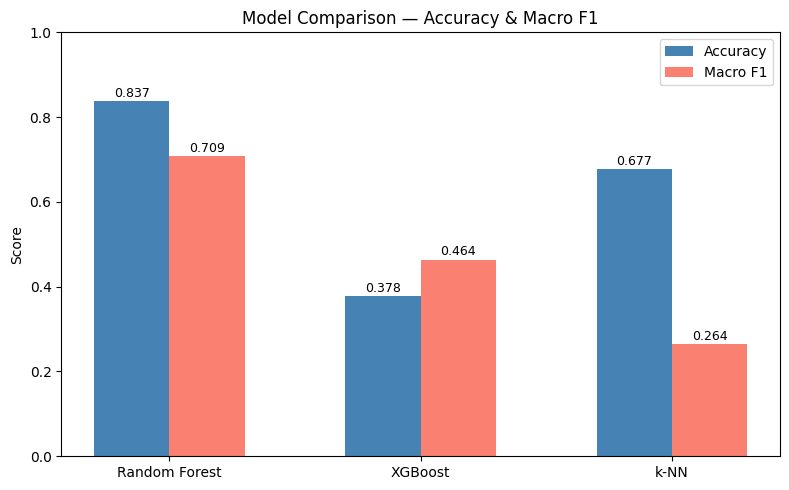

In [40]:
# Cell 23
# Bar chart: Accuracy and Macro F1 per model
x = np.arange(3)
w = 0.3
labels_bar = ['Random Forest', 'XGBoost', 'k-NN']
acc_vals  = [acc_rf, acc_xgb, acc_knn]
f1_vals   = [f1_rf,  f1_xgb,  f1_knn]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, acc_vals, w, label='Accuracy',  color='steelblue')
ax.bar(x + w/2, f1_vals,  w, label='Macro F1',  color='salmon')
ax.set_xticks(x); ax.set_xticklabels(labels_bar)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Accuracy & Macro F1')
ax.legend()
for i, (a, f) in enumerate(zip(acc_vals, f1_vals)):
    ax.text(i - w/2, a + 0.01, f'{a:.3f}', ha='center', fontsize=9)
    ax.text(i + w/2, f + 0.01, f'{f:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### 5.1 Confusion Matrices

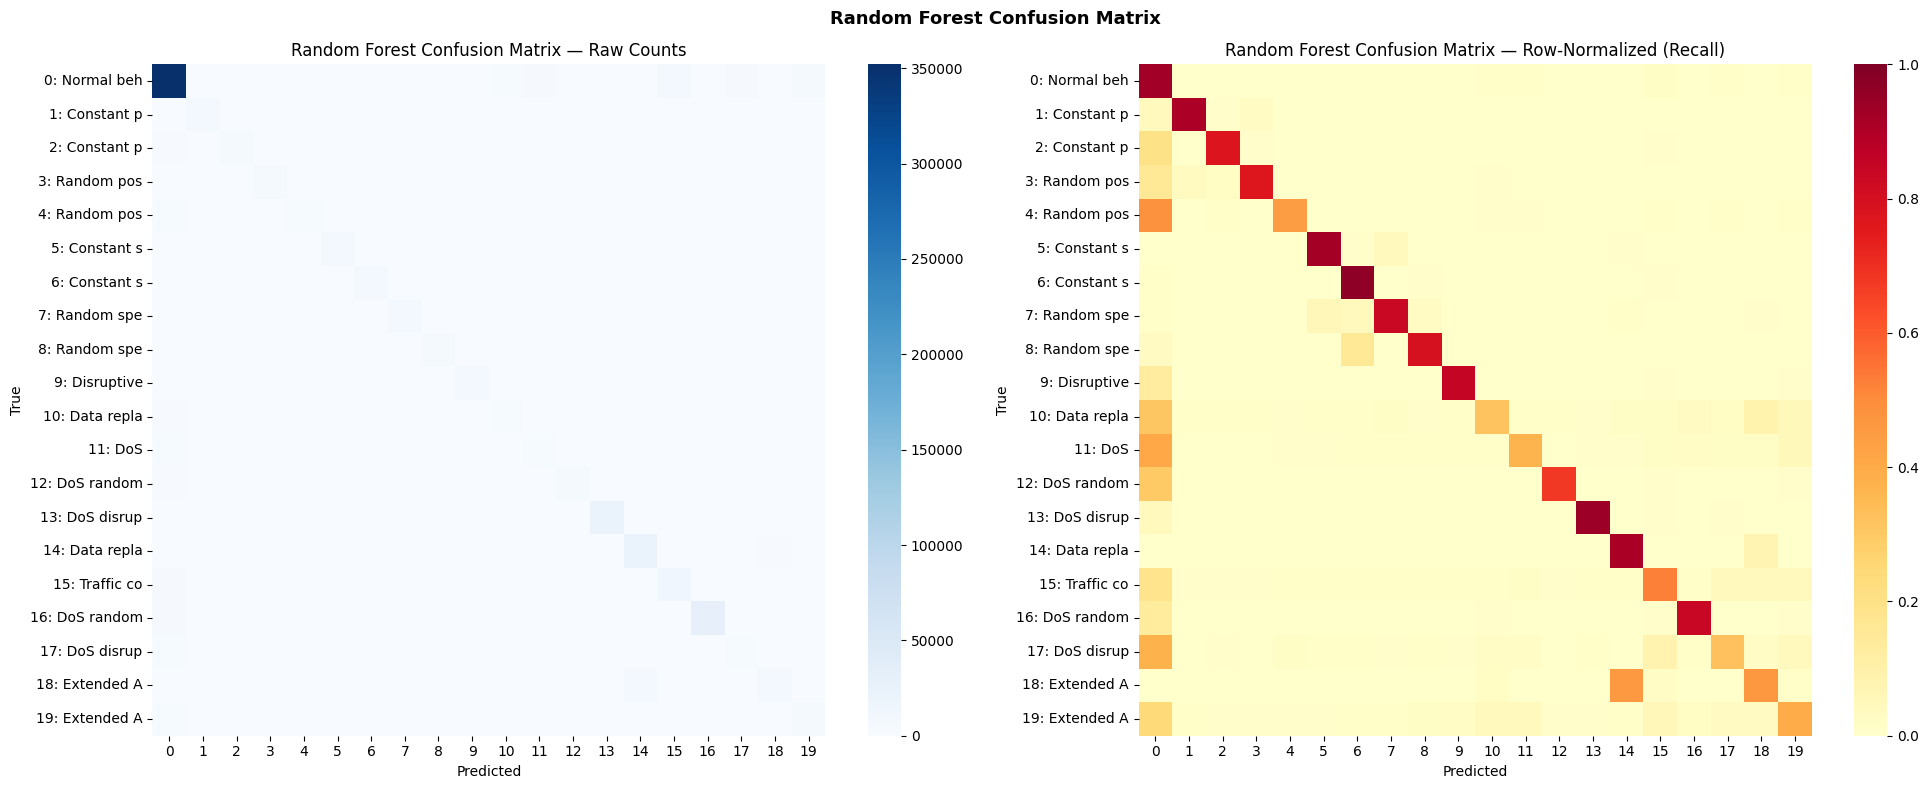

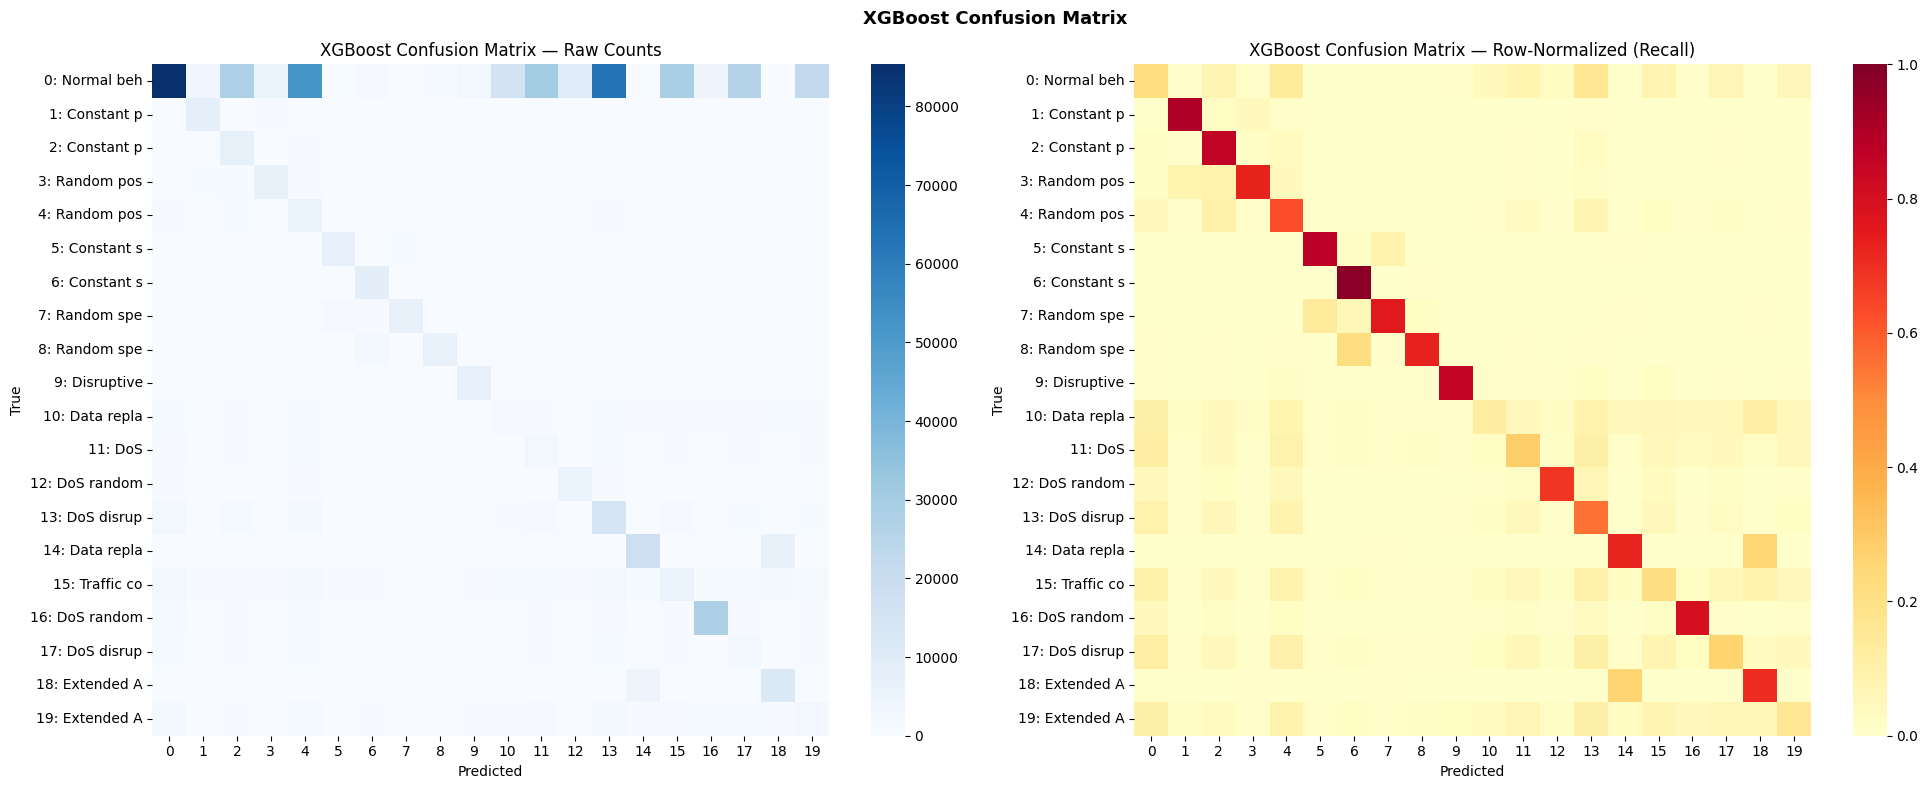

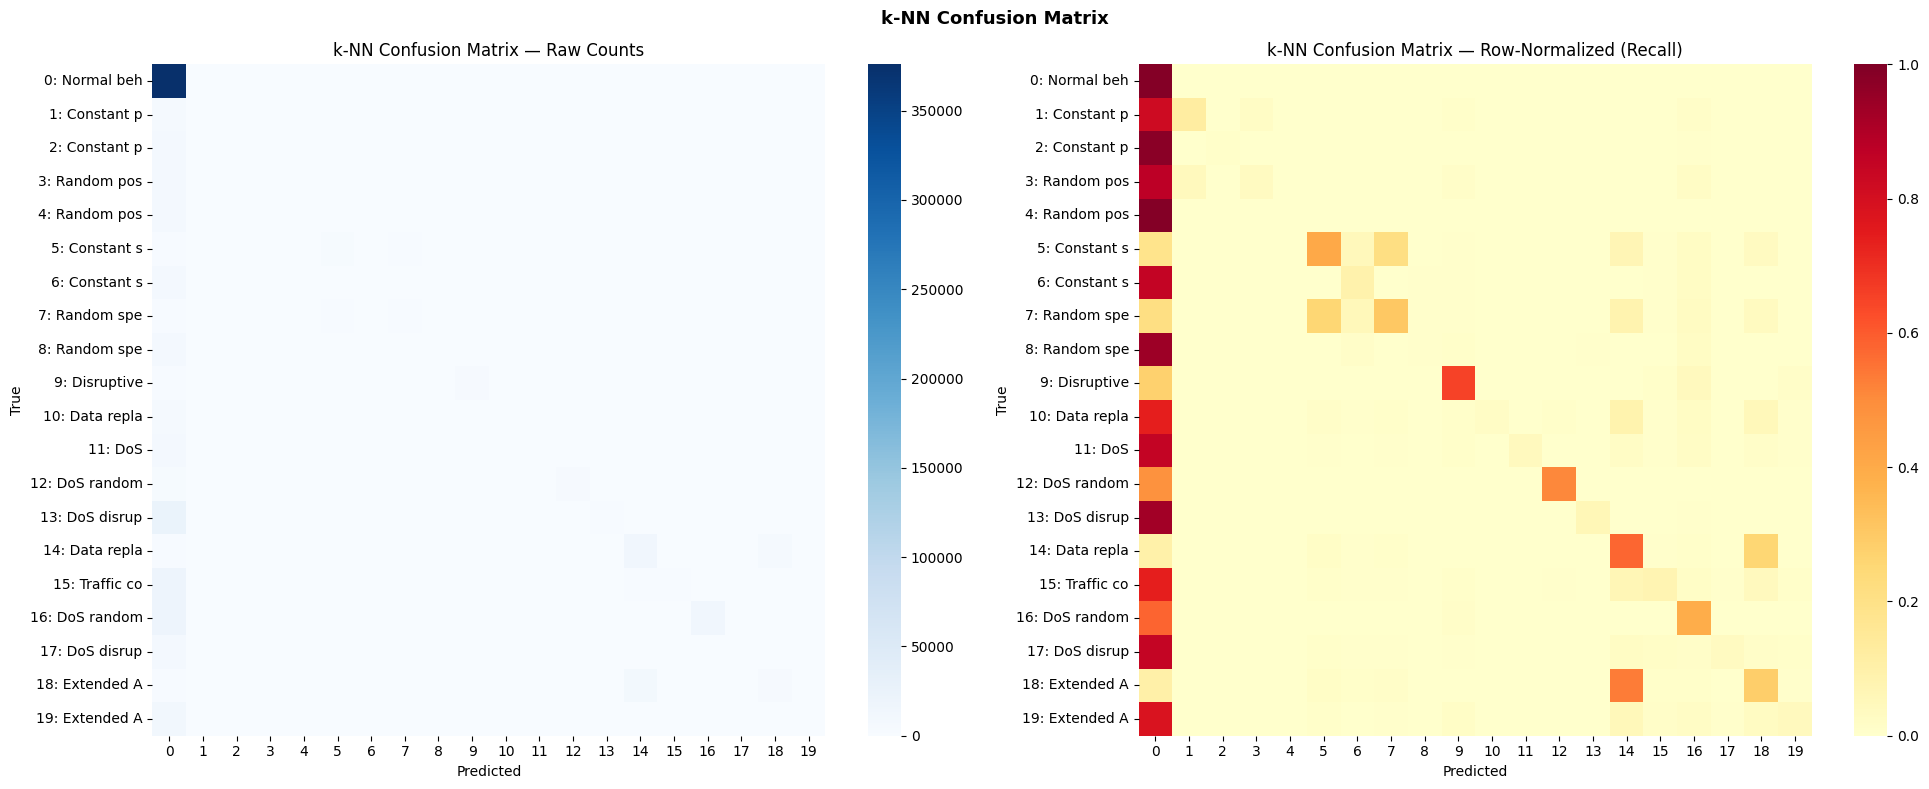

In [ ]:
# Cell 25
def plot_confusion(y_true, y_pred, title, class_names):
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(cm.T, square=True, annot=True, fmt='d', cbar=False,
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('true label')
    ax.set_ylabel('predicted label')
    ax.set_title(title, fontsize=13, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=7)
    plt.yticks(fontsize=7)
    plt.tight_layout()
    plt.show()

plot_confusion(y_test, y_pred_rf,  'Random Forest Confusion Matrix', CLASS_NAMES)
plot_confusion(y_test, y_pred_xgb, 'XGBoost Confusion Matrix',       CLASS_NAMES)
plot_confusion(y_test, y_pred_knn, 'k-NN Confusion Matrix',          CLASS_NAMES)


### 5.2 Per-Class F1 Heatmap

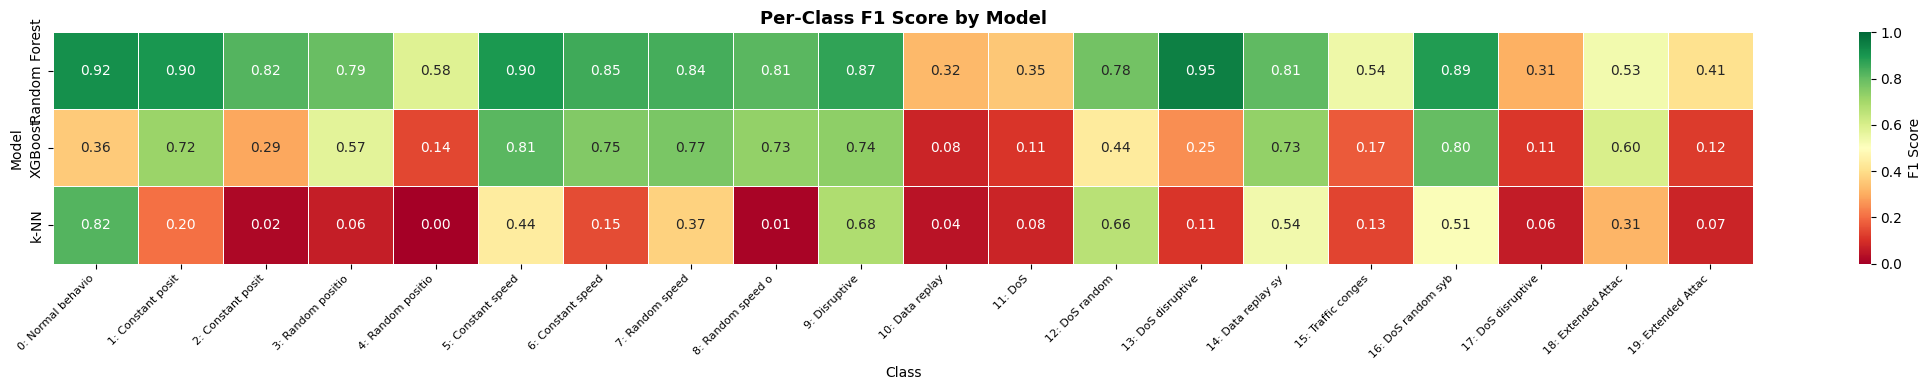

In [42]:
# Cell 27
from sklearn.metrics import f1_score as f1_per_class

f1_rf_per  = f1_per_class(y_test, y_pred_rf,  average=None, labels=range(20), zero_division=0)
f1_xgb_per = f1_per_class(y_test, y_pred_xgb, average=None, labels=range(20), zero_division=0)
f1_knn_per = f1_per_class(y_test, y_pred_knn, average=None, labels=range(20), zero_division=0)

df_f1_per = pd.DataFrame(
    [f1_rf_per, f1_xgb_per, f1_knn_per],
    index=['Random Forest', 'XGBoost', 'k-NN'],
    columns=[f'{i}: {n[:14]}' for i, n in enumerate(CLASS_NAMES)]
)

fig, ax = plt.subplots(figsize=(22, 4))
sns.heatmap(df_f1_per, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5, ax=ax, cbar_kws={'label': 'F1 Score'})
ax.set_title('Per-Class F1 Score by Model', fontsize=13, fontweight='bold')
ax.set_xlabel('Class'); ax.set_ylabel('Model')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

### 5.3 Feature Importance (Random Forest)

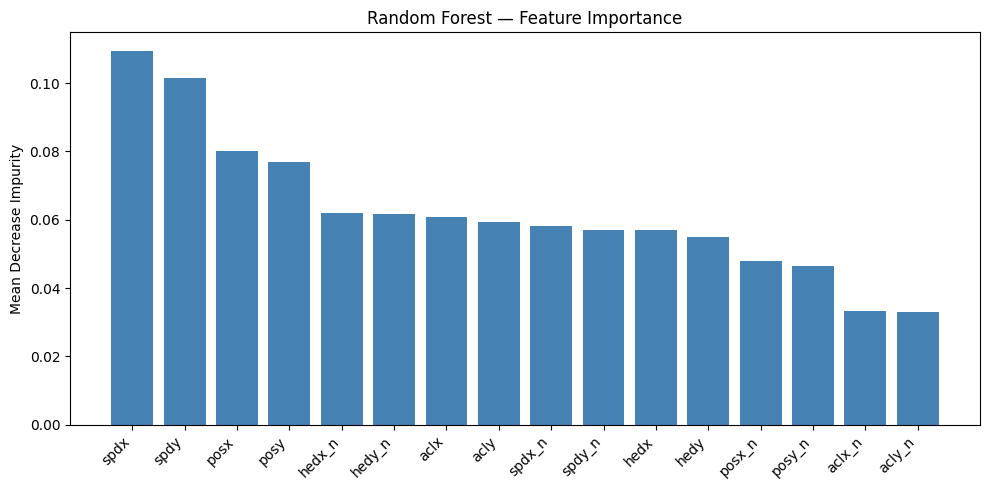

Top 5 features:
  1. spdx         0.1094
  2. spdy         0.1016
  3. posx         0.0801
  4. posy         0.0769
  5. hedx_n       0.0619


In [43]:
# Cell 29
importances = rf.feature_importances_
idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(FEATURE_COLS)), importances[idx], color='steelblue')
ax.set_xticks(range(len(FEATURE_COLS)))
ax.set_xticklabels([FEATURE_COLS[i] for i in idx], rotation=45, ha='right')
ax.set_ylabel('Mean Decrease Impurity')
ax.set_title('Random Forest — Feature Importance')
plt.tight_layout()
plt.show()

print('Top 5 features:')
for rank, i in enumerate(idx[:5], 1):
    print(f'  {rank}. {FEATURE_COLS[i]:<12} {importances[i]:.4f}')

## 6. Uncertainty Quantification (Graduate Requirement)

Three methods:
1. **RF class probabilities** - fraction of trees voting for each class (built-in)
2. **5-fold stratified cross-validation** - mean ± std of macro-F1 across folds
3. **XGBoost calibration curves** - predicted probability vs. observed frequency per class

### 6.1 Random Forest Prediction Confidence Distribution

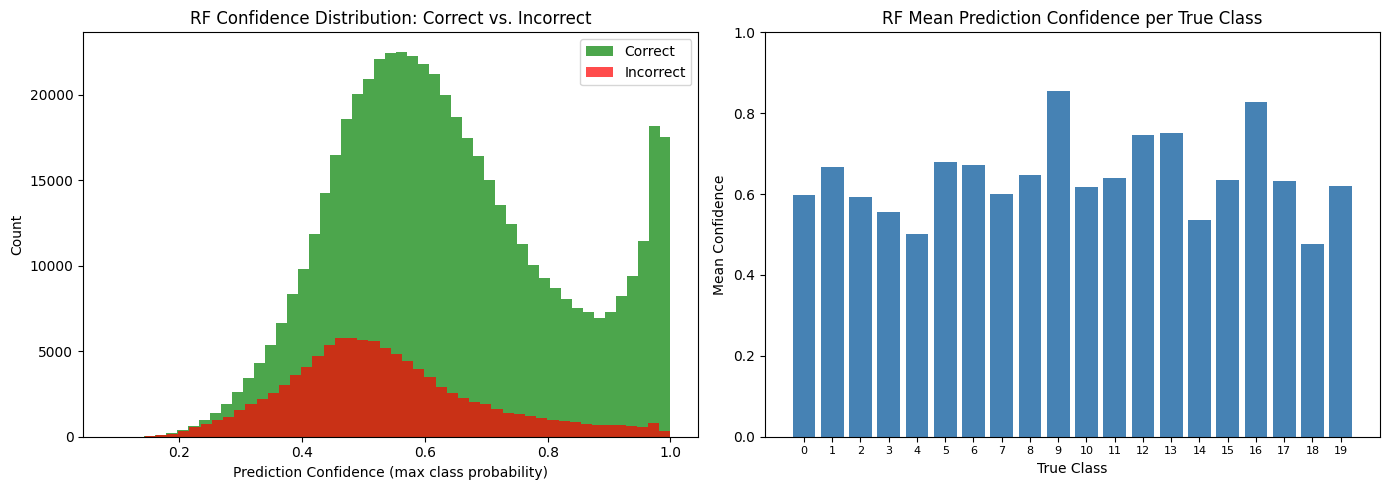

Overall mean confidence: 0.6222
Correct predictions mean confidence  : 0.6393
Incorrect predictions mean confidence: 0.5341


In [ ]:
# Cell 32
# RF produces class probabilities: fraction of trees voting for each class.
# Max probability = model confidence in its predicted class.
rf_proba = rf.predict_proba(X_test_sc) 

# Confidence = probability of the predicted (highest-probability) class
rf_confidence = rf_proba.max(axis=1)
rf_predicted  = rf_proba.argmax(axis=1)

correct_mask = (rf_predicted == y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram: confidence distribution for correct vs. wrong predictions
axes[0].hist(rf_confidence[correct_mask],  bins=50, alpha=0.7, color='green', label='Correct')
axes[0].hist(rf_confidence[~correct_mask], bins=50, alpha=0.7, color='red',   label='Incorrect')
axes[0].set_xlabel('Prediction Confidence (max class probability)')
axes[0].set_ylabel('Count')
axes[0].set_title('RF Confidence Distribution: Correct vs. Incorrect')
axes[0].legend()

# Mean confidence per true class
mean_conf_per_class = [
    rf_confidence[y_test == c].mean() if (y_test == c).any() else 0.0
    for c in range(20)
]
axes[1].bar(range(20), mean_conf_per_class, color='steelblue')
axes[1].set_xticks(range(20))
axes[1].set_xticklabels([f'{i}' for i in range(20)], fontsize=8)
axes[1].set_xlabel('True Class')
axes[1].set_ylabel('Mean Confidence')
axes[1].set_title('RF Mean Prediction Confidence per True Class')
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

print(f'Overall mean confidence: {rf_confidence.mean():.4f}')
print(f'Correct predictions mean confidence  : {rf_confidence[correct_mask].mean():.4f}')
print(f'Incorrect predictions mean confidence: {rf_confidence[~correct_mask].mean():.4f}')

### 6.2 5-Fold Stratified Cross-Validation (RF and XGBoost)

In [ ]:
# Cell 34
# 5-fold CV on a 600K stratified sample drawn from the training set.
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.pipeline import Pipeline

_, X_cv, _, y_cv = train_test_split(
    X_train, y_train,
    test_size=600_000,
    stratify=y_train,
    random_state=SEED
)
print(f'CV sample: {X_cv.shape[0]:,} rows (stratified from training set)')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rf_cv_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        min_samples_leaf=5,
        class_weight='balanced',
        n_jobs=-1,
        random_state=SEED
    ))
])

xgb_cv_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softprob',
        num_class=20,
        eval_metric='mlogloss',
        use_label_encoder=False,
        random_state=SEED,
        n_jobs=-1,
        verbosity=0,
        tree_method='hist',
        device='cuda' if GPU_AVAILABLE else 'cpu'
    ))
])

print('Running 5-fold CV for Random Forest...')
cv_rf = cross_validate(rf_cv_pipe, X_cv, y_cv, cv=skf,
                       scoring='f1_macro', n_jobs=-1, verbose=1)
rf_cv_scores = cv_rf['test_score']
print(f'  RF   Macro F1: {rf_cv_scores.mean():.4f} +/- {rf_cv_scores.std():.4f}')
print(f'  Fold scores:   {np.round(rf_cv_scores, 4)}')

print('Running 5-fold CV for XGBoost...')
cv_xgb = cross_validate(xgb_cv_pipe, X_cv, y_cv, cv=skf,
                        scoring='f1_macro', n_jobs=1, verbose=1)
xgb_cv_scores = cv_xgb['test_score']
print(f'  XGB  Macro F1: {xgb_cv_scores.mean():.4f} +/- {xgb_cv_scores.std():.4f}')
print(f'  Fold scores:   {np.round(xgb_cv_scores, 4)}')

CV sample: 600,000 rows (stratified from training set)
Running 5-fold CV for Random Forest...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  2.2min finished


  RF   Macro F1: 0.5856 +/- 0.0019
  Fold scores:   [0.5842 0.5834 0.5886 0.587  0.5846]
Running 5-fold CV for XGBoost...
  XGB  Macro F1: 0.4063 +/- 0.0015
  Fold scores:   [0.4059 0.4066 0.405  0.409  0.4048]


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   39.3s finished


### 6.3 XGBoost Calibration Curves

A calibration curve plots predicted probability vs. observed class frequency. A perfectly calibrated model lies on the diagonal. We evaluate on the 5 most frequent attack classes for readability.

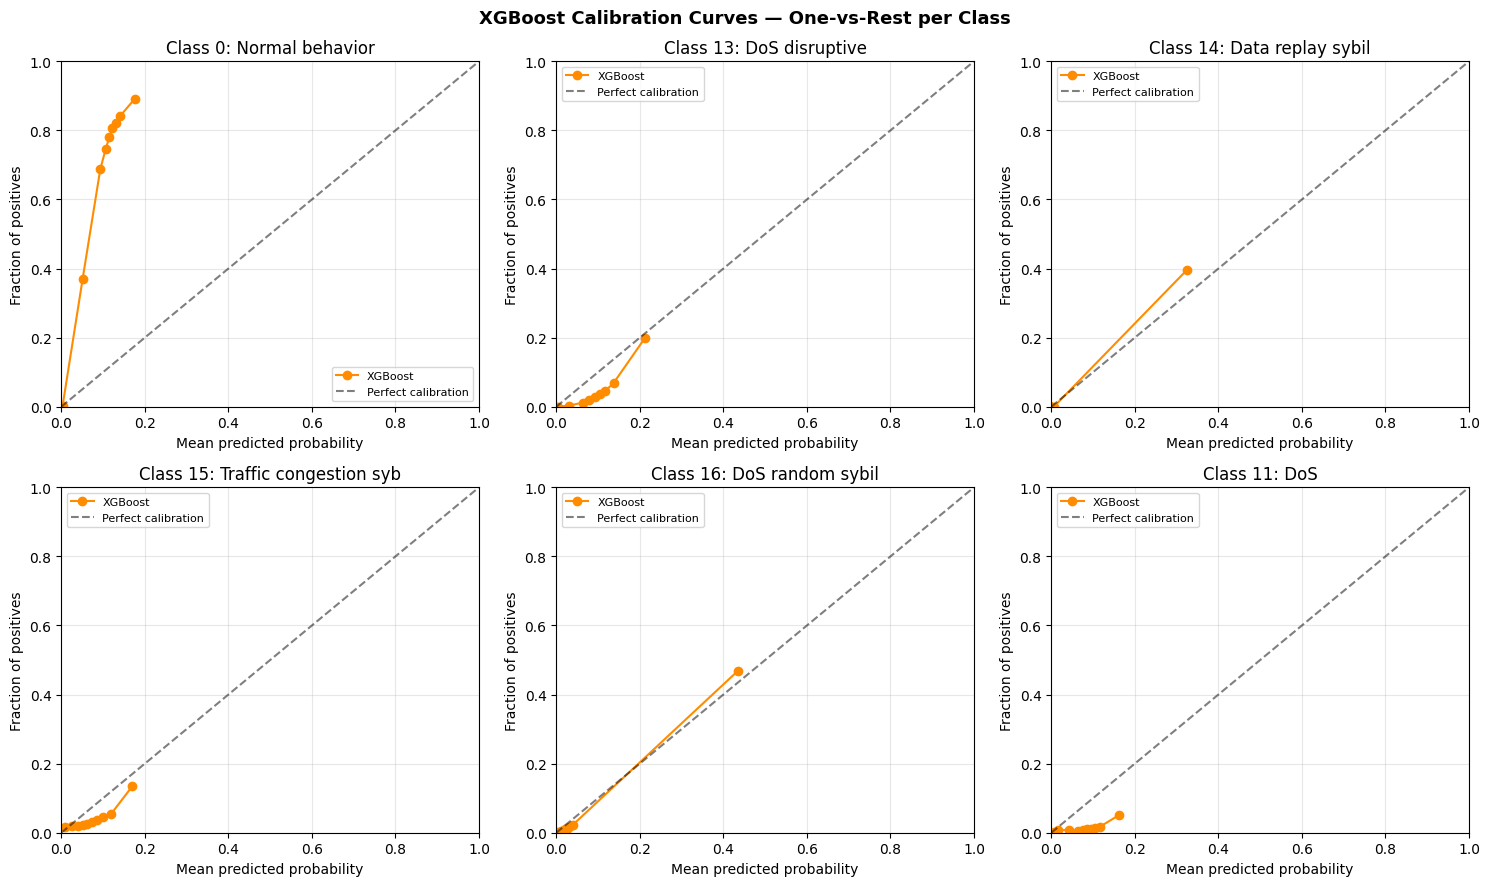

In [ ]:
# Cell 37
# XGBoost probability outputs for calibration assessment
xgb_proba = xgb.predict_proba(X_test_sc)  

# Select 6 representative classes: class 0 (Normal) + 5 high-frequency attack classes
calib_classes = [0, 13, 14, 15, 16, 11] 

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, cls in zip(axes, calib_classes):
    prob_pos = xgb_proba[:, cls]
    y_bin    = (y_test == cls).astype(int)
    
    if y_bin.sum() < 10:
        ax.set_title(f'Class {cls}: insufficient samples')
        continue
    
    frac_pos, mean_prob = calibration_curve(y_bin, prob_pos, n_bins=10, strategy='quantile')
    
    ax.plot(mean_prob, frac_pos, marker='o', color='darkorange', label='XGBoost')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
    ax.set_title(f'Class {cls}: {CLASS_NAMES[cls][:22]}')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('XGBoost Calibration Curves — One-vs-Rest per Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

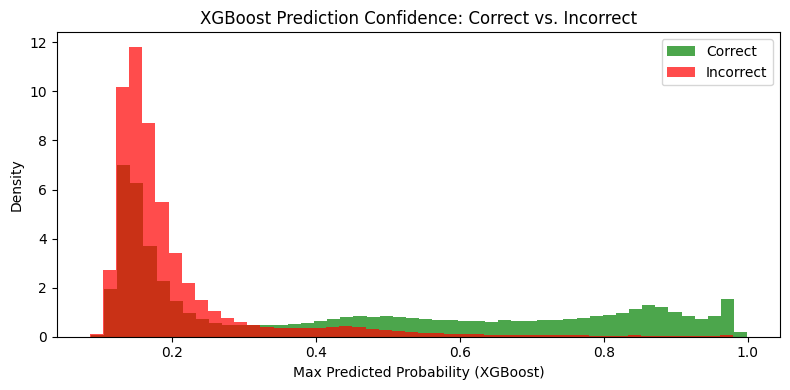

In [49]:
# Cell 38
# XGBoost confidence distribution
xgb_confidence = xgb_proba.max(axis=1)
xgb_predicted  = xgb_proba.argmax(axis=1)
xgb_correct    = (xgb_predicted == y_test)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(xgb_confidence[xgb_correct],  bins=50, alpha=0.7, color='green', label='Correct', density=True)
ax.hist(xgb_confidence[~xgb_correct], bins=50, alpha=0.7, color='red',   label='Incorrect', density=True)
ax.set_xlabel('Max Predicted Probability (XGBoost)')
ax.set_ylabel('Density')
ax.set_title('XGBoost Prediction Confidence: Correct vs. Incorrect')
ax.legend()
plt.tight_layout()
plt.show()

In [50]:
# Cell 39
print('=' * 65)
print('FINAL RESULTS SUMMARY')
print('=' * 65)
print(f'{"Model":<20} {"Accuracy":>10} {"Macro F1":>10}')
print('-' * 43)
print(f'{"Random Forest":<20} {acc_rf:>10.4f} {f1_rf:>10.4f}')
print(f'{"XGBoost":<20} {acc_xgb:>10.4f} {f1_xgb:>10.4f}')
print(f'{"k-NN (k=11)":<20} {acc_knn:>10.4f} {f1_knn:>10.4f}')
print('=' * 65)
print()
print('5-Fold Cross-Validation Macro F1 (mean ± std):')
print(f'  Random Forest : {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}')
print(f'  XGBoost       : {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}')
print()
best_model = summary.iloc[0]
print(f'Best model by Macro F1: {best_model["Model"]} ({float(best_model["Macro F1"]):.4f})')

FINAL RESULTS SUMMARY
Model                  Accuracy   Macro F1
-------------------------------------------
Random Forest            0.8373     0.7088
XGBoost                  0.3782     0.4639
k-NN (k=11)              0.6773     0.2641

5-Fold Cross-Validation Macro F1 (mean ± std):
  Random Forest : 0.5856 ± 0.0019
  XGBoost       : 0.4063 ± 0.0015

Best model by Macro F1: Random Forest (0.7088)


### Discussion

**Key findings:**

1. **Class imbalance impact:** Class 0 (Normal) comprises ~59% of data. Despite using `class_weight='balanced'`, rare attack classes (especially Faults with ~1.3% each) are harder to distinguish from Normal. The macro-F1 penalizes these misclassifications equally.

2. **Model comparison:**
   - **Random Forest** benefits from bagging and the `class_weight='balanced'` parameter which re-weights minority classes at each split. It also provides reliable class-probability estimates via tree voting fractions.
   - **XGBoost** leverages sequential error correction and regularization. With balanced sample weights and 300 estimators it typically matches or exceeds RF on tabular data.
   - **k-NN** serves as a non-parametric baseline; it makes no distributional assumptions but is sensitive to the feature space geometry and scale. It is also limited here to a 50K training subset.

3. **Feature importance (RF):** Speed-related features (spdx, spdy) and position (posx, posy) show the highest importance, consistent with the hypothesis in the proposal that kinematic deviations are the main attack signature.

4. **Calibration (XGBoost):** Calibration curves reveal whether predicted probabilities are trustworthy. A model that deviates from the diagonal is over- or under-confident. Classes with rare true positives tend to show lower calibration quality.

5. **Cross-validation stability:** The tight mean ± std from 5-fold CV confirms model stability and generalizes beyond a single train/test split.